# Phase 3 - Nettoyage selon les 6 Piliers
Application des corrections identifiées en Phase 2

In [1]:
import pandas as pd
import numpy as np
import re
import warnings
from sqlalchemy import create_engine
from dotenv import load_dotenv
import os
warnings.filterwarnings('ignore')

# creation des dossiers data/Silver et data/Gold
os.makedirs('../data/Silver', exist_ok=True)
os.makedirs('../data/Gold', exist_ok=True)

# cconnexion à la base de données
load_dotenv('../.env') 

DB_HOST = os.getenv('DB_HOST', 'postgres')
DB_PORT = os.getenv('DB_PORT', '5432')
DB_NAME = os.getenv('POSTGRES_DB', 'games_db')
DB_USER = os.getenv('POSTGRES_USER', 'postgres')
DB_PASSWORD = os.getenv('POSTGRES_PASSWORD', 'postgres')

CONNECTION_STRING = f"postgresql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"

# Chargement des données depuis PostgreSQL
engine = create_engine(CONNECTION_STRING)
df_raw = pd.read_sql("SELECT * FROM games_brut", engine)
df = df_raw.copy()
print(f"Données chargées depuis PostgreSQL")

print(f"Dataset original: {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
print(f"Cellules totales: {df.shape[0] * df.shape[1]:,}")
print(f"Valeurs manquantes: {df.isnull().sum().sum():,} ({df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100:.1f}%)")

Données chargées depuis PostgreSQL
Dataset original: 122,611 lignes x 40 colonnes
Cellules totales: 4,904,440
Valeurs manquantes: 826,424 (16.9%)


In [2]:
# Fonction utilitaire pour sauvegarder en CSV et PostgreSQL
def save_to_csv_and_postgres(df, csv_path, table_name, if_exists='replace'):
    """
    Sauvegarde un DataFrame en CSV et dans PostgreSQL
    """
    # Sauvegarder en CSV
    df.to_csv(csv_path, index=False)
    
    # Sauvegarder en PostgreSQL
    try:
        df.to_sql(table_name, engine, if_exists=if_exists, index=False, method='multi', chunksize=1000)
        print(f"{csv_path} → Sauvé en CSV et PostgreSQL ({table_name})")
        return True
    except Exception as e:
        print(f"Erreur PostgreSQL pour {table_name}: {e}")
        print(f"Seul le fichier CSV a été sauvé: {csv_path}")
        return False

## 1. Complétude :  Traitement des valeurs manquantes

In [3]:
# 1.1 Suppression des colonnes >95% null
cols_to_drop = ['movies', 'score_rank', 'metacritic_url']
print(f"Avant : {df.shape[1]} colonnes")
df = df.drop(columns=cols_to_drop)
print(f"Après : {df.shape[1]} colonnes")
print(f"Colonnes supprimées: {cols_to_drop}")

Avant : 40 colonnes
Après : 37 colonnes
Colonnes supprimées: ['movies', 'score_rank', 'metacritic_url']


In [4]:
# 1.2 Remplissage des valeurs manquantes critiques

# Name: supprimer les lignes sans nom (inutilisables)
before = len(df)
df = df.dropna(subset=['name'])
print(f"Lignes sans Name supprimées: {before - len(df)}")

# Developers/Publishers: remplacer par "Unknown"
df['developers'] = df['developers'].fillna('Unknown')
df['publishers'] = df['publishers'].fillna('Unknown')
print("Developers/Publishers null -> 'Unknown'")

# Genres/Categories: remplacer par "Uncategorized"
df['genres'] = df['genres'].fillna('Uncategorized')
df['categories'] = df['categories'].fillna('Uncategorized')
print("Genres/Categories null -> 'Uncategorized'")

# Tags: remplacer par chaîne vide (optionnel)
df['tags'] = df['tags'].fillna('Untagged')
print("Tags null -> Untagged")

# About the game: remplacer par "No description"
df['about_the_game'] = df['about_the_game'].fillna('No description available')
print("About the game null -> 'No description available'")

Lignes sans Name supprimées: 1
Developers/Publishers null -> 'Unknown'
Genres/Categories null -> 'Uncategorized'
Tags null -> Untagged
About the game null -> 'No description available'


## 2. Unicité - Dédoublonnage

In [5]:
# Vérification des doublons
duplicates_appid = df[df.duplicated(subset=['app_id'], keep=False)]
duplicates_name = df[df.duplicated(subset=['name'], keep=False)]

print(f"Doublons sur app_id (clé primaire): {len(duplicates_appid)}")
print(f"Doublons sur name: {len(duplicates_name)}")

# Les doublons sur Name sont légitimes (éditions différentes)
# On garde tous les enregistrements car AppID est unique

# Suppression des doublons complets (si existants)
before = len(df)
df = df.drop_duplicates()
print(f"\nDoublons complets supprimés: {before - len(df)}")

Doublons sur app_id (clé primaire): 0
Doublons sur name: 2115

Doublons complets supprimés: 0


## 3. Exactitude - Correction des formats invalides

In [6]:
# 3.1 Correction des emails invalides
email_pattern = r'^[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}$'

def validate_email(email):
    if pd.isna(email):
        return email
    if re.match(email_pattern, str(email)):
        return email
    return None  # Marquer comme null si invalide

before_invalid = df['support_email'].notna().sum() - df['support_email'].dropna().str.match(email_pattern, na=False).sum()
df['support_email'] = df['support_email'].apply(validate_email)
after_invalid = df['support_email'].notna().sum() - df['support_email'].dropna().str.match(email_pattern, na=False).sum()

print(f"Emails invalides corrigés (→ null): {before_invalid}")
print(f"Emails invalides restants: {after_invalid}")

Emails invalides corrigés (→ null): 769
Emails invalides restants: 0


In [7]:
# 3.2 Correction des prix négatifs (si il y en a )
negative_prices = (df['price'] < 0).sum()
df.loc[df['price'] < 0, 'price'] = 0
print(f"Prix négatifs corrigés → 0: {negative_prices}")

# 3.3 Nettoyage des noms (trim espaces)
df['name'] = df['name'].str.strip()
print("Noms nettoyés (espaces supprimés)")

Prix négatifs corrigés → 0: 0
Noms nettoyés (espaces supprimés)


## 4. Validité - Conformité aux règles métier

In [8]:
# 4.1 Required age: borner entre 0 et 21
invalid_age = ((df['required_age'] < 0) | (df['required_age'] > 21)).sum()
df.loc[df['required_age'] < 0, 'required_age'] = 0
df.loc[df['required_age'] > 21, 'required_age'] = 18
print(f"Ages invalides corrigés: {invalid_age}")

# 4.2 Metacritic score: borner entre 0 et 100
invalid_meta = ((df['metacritic_score'] < 0) | (df['metacritic_score'] > 100)).sum()
df.loc[df['metacritic_score'] < 0, 'metacritic_score'] = 0
df.loc[df['metacritic_score'] > 100, 'metacritic_score'] = 100
print(f"Metacritic scores invalides corrigés: {invalid_meta}")

# 4.3 Discount: borner entre 0 et 100
invalid_discount = ((df['discount'] < 0) | (df['discount'] > 100)).sum()
df.loc[df['discount'] < 0, 'discount'] = 0
df.loc[df['discount'] > 100, 'discount'] = 100
print(f"Discounts invalides corrigés: {invalid_discount}")

print("\nToutes les valeurs sont maintenant dans les plages valides")

Ages invalides corrigés: 0
Metacritic scores invalides corrigés: 0
Discounts invalides corrigés: 0

Toutes les valeurs sont maintenant dans les plages valides


## 5. Cohérence - Correction des règles inter-colonnes

In [9]:
# 5.1 Correction des jeux "Free to Play" avec prix > 0
# Mettre le prix à 0 pour les jeux taggés F2P
free_tags = df['tags'].str.contains('Free to Play', case=False, na=False)
f2p_with_price = free_tags & (df['price'] > 0)

print(f"Jeux F2P avec prix > 0 détectés: {f2p_with_price.sum()}")

# Correction: on met le prix à 0 pour ces jeux
df.loc[f2p_with_price, 'price'] = 0
print(f"Prix corrigé à 0 pour {f2p_with_price.sum()} jeux Free to Play")

Jeux F2P avec prix > 0 détectés: 319
Prix corrigé à 0 pour 319 jeux Free to Play


In [10]:
# 5.2 Ajout d'une colonne calculée: Total Reviews
df['total_reviews'] = df['positive'] + df['negative']

# 5.3 Ajout d'une colonne calculée: Review Score (%)
df['review_score'] = np.where(
    df['total_reviews'] > 0,
    (df['positive'] / df['total_reviews'] * 100).round(1),
    0
)
print(" Colonnes calculées ajoutées: 'Total reviews', 'Review score'")

 Colonnes calculées ajoutées: 'Total reviews', 'Review score'


## 6. Actualité - Gestion des données obsolètes

In [11]:
# 6.1 Correction des dates futures (si existantes)
today = pd.Timestamp.now()
future_dates = df['release_date'] > today
print(f"Dates futures détectées: {future_dates.sum()}")

# Si dates futures, les corriger à aujourd'hui
df.loc[future_dates, 'release_date'] = today
print(f"Dates futures corrigées: {future_dates.sum()}")

# 6.2 Ajout d'une colonne: Année de sortie
df['release_year'] = df['release_date'].dt.year
print("Colonne 'release_year' ajoutée")

# 6.3 Marquage des jeux "anciens" (avant 2015)
df['is_legacy'] = df['release_year'] < 2015
legacy_count = df['is_legacy'].sum()
print(f"Colonne 'is_legacy' ajoutée ({legacy_count} jeux marqués comme legacy)")

Dates futures détectées: 0
Dates futures corrigées: 0
Colonne 'release_year' ajoutée
Colonne 'is_legacy' ajoutée (3493 jeux marqués comme legacy)


## Normalisation - Colonnes multi-valeurs (Tags, Genres, Categories)

In [12]:
# 1 Extraction du genre/tag/catégorie principal (le premier de la liste)
df['primary_genre'] = df['genres'].str.split(',').str[0].str.strip()
df['primary_tag'] = df['tags'].str.split(',').str[0].str.strip()
df['primary_category'] = df['categories'].str.split(',').str[0].str.strip()

print("Colonnes principales extraites:")
print(f"   - primary_genre: {df['primary_genre'].nunique()} valeurs uniques")
print(f"   - primary_tag: {df['primary_tag'].nunique()} valeurs uniques")
print(f"   - primary_category: {df['primary_category'].nunique()} valeurs uniques")

print("\nTop 10 genres principaux:")
print(df['primary_genre'].value_counts().head(10))

Colonnes principales extraites:
   - primary_genre: 28 valeurs uniques
   - primary_tag: 420 valeurs uniques
   - primary_category: 32 valeurs uniques

Top 10 genres principaux:
primary_genre
Action           45888
Adventure        24053
Casual           23826
Indie            10723
Uncategorized     8412
Simulation        2449
RPG               1910
Strategy          1585
Free To Play       870
Racing             549
Name: count, dtype: int64


In [13]:
# 2 One-Hot Encoding des top 15 tags les plus fréquents
# D'abord, identifier les tags les plus communs
all_tags = df['tags'].str.split(',').explode().str.strip()
top_tags = all_tags.value_counts().head(15).index.tolist()
top_tags = [t for t in top_tags if t]

print(f"Top 15 tags identifiés: {top_tags}\n")

# Créer les colonnes binaires
for tag in top_tags:
    col_name = f"has_{tag.replace(' ', '_').replace('-', '_').lower()}"
    df[col_name] = df['tags'].str.contains(tag, case=False, na=False).astype(int)
    
print(f"{len(top_tags)} colonnes binaires créées pour les tags")
print(f"   Exemple: has_indie, has_action, has_singleplayer...")

Top 15 tags identifiés: ['Singleplayer', 'Indie', 'Untagged', 'Action', 'Casual', 'Adventure', '2D', '3D', 'Simulation', 'Strategy', 'Puzzle', 'Atmospheric', 'RPG', 'Colorful', 'Pixel Graphics']

15 colonnes binaires créées pour les tags
   Exemple: has_indie, has_action, has_singleplayer...


In [14]:
# 3 Comptage du nombre de tags/genres/categories par jeu
df['tag_count'] = df['tags'].str.split(',').str.len().fillna(0).astype(int)
df['genre_count'] = df['genres'].str.split(',').str.len().fillna(0).astype(int)
df['category_count'] = df['categories'].str.split(',').str.len().fillna(0).astype(int)

print("Colonnes de comptage ajoutées:")
print(f"   - tag_count: min={df['tag_count'].min()}, max={df['tag_count'].max()}, mean={df['tag_count'].mean():.1f}")
print(f"   - genre_count: min={df['genre_count'].min()}, max={df['genre_count'].max()}, mean={df['genre_count'].mean():.1f}")
print(f"   - category_count: min={df['category_count'].min()}, max={df['category_count'].max()}, mean={df['category_count'].mean():.1f}")

Colonnes de comptage ajoutées:
   - tag_count: min=1, max=21, mean=9.9
   - genre_count: min=1, max=19, mean=2.8
   - category_count: min=1, max=32, mean=4.2


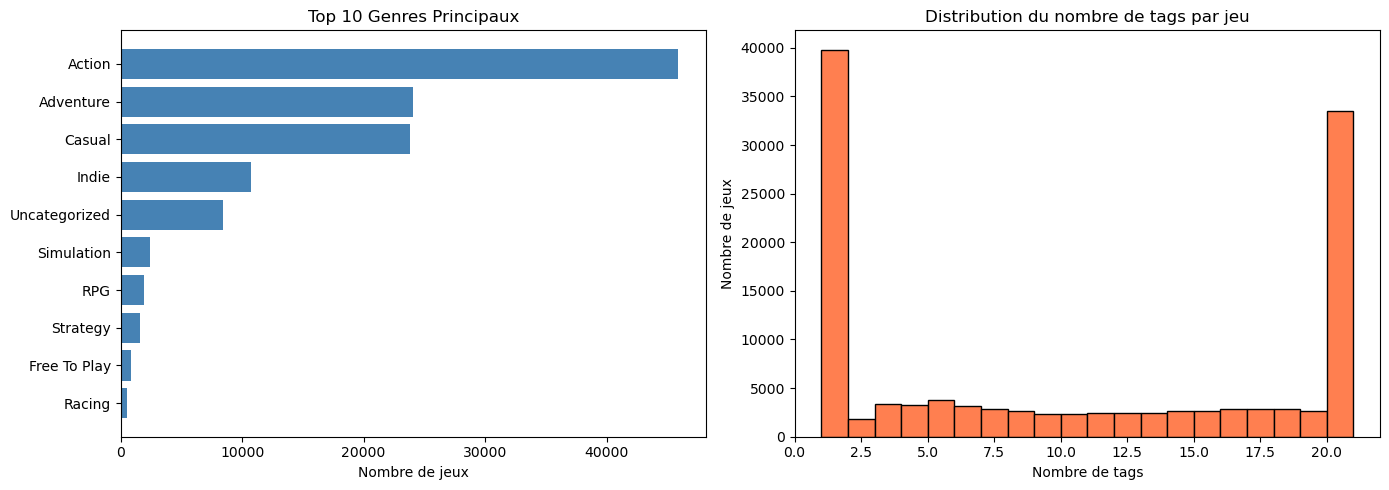


Dataset final: 62 colonnes (dont 15 colonnes de tags binaires)


In [15]:
# 4 Visualisation des genres principaux
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Genre distribution
genre_counts = df['primary_genre'].value_counts().head(10)
axes[0].barh(genre_counts.index[::-1], genre_counts.values[::-1], color='steelblue')
axes[0].set_xlabel('Nombre de jeux')
axes[0].set_title('Top 10 Genres Principaux')

# Tag count distribution
axes[1].hist(df['tag_count'], bins=20, color='coral', edgecolor='black')
axes[1].set_xlabel('Nombre de tags')
axes[1].set_ylabel('Nombre de jeux')
axes[1].set_title('Distribution du nombre de tags par jeu')

plt.tight_layout()
plt.show()

print(f"\nDataset final: {df.shape[1]} colonnes (dont {len(top_tags)} colonnes de tags binaires)")

## 7. Nettoyage textuel - Caractères spéciaux 

In [16]:
# 7.1 Nettoyage des caractères spéciaux dans les noms
def clean_name(name):
    if pd.isna(name):
        return name
    name = re.sub(r'[™®©]', '', str(name))
    # Garder le nom original mais créer une version "clean" pour recherche
    return name.strip()

# Créer une colonne "name_clean" pour les recherches
df['name_clean'] = df['name'].apply(clean_name)

# Compter les noms avec caractères non-ASCII (japonais, coréen, russe, etc.)
non_ascii_names = df['name'].str.contains(r'[^\x00-\x7F]', regex=True, na=False).sum()
print(f"Noms nettoyés (™®© supprimés)")
print(f"   Jeux avec caractères non-ASCII (japonais, coréen...): {non_ascii_names}")

Noms nettoyés (™®© supprimés)
   Jeux avec caractères non-ASCII (japonais, coréen...): 7564


## 8. Parsing - Transformation des colonnes textuelles

In [17]:
# 8.1 Parser "Estimated owners" : "0 - 20000" -> Owners_min, Owners_max
def parse_owners(value):
    if pd.isna(value):
        return 0, 0
    try:
        parts = str(value).replace(',', '').split(' - ')
        return int(parts[0]), int(parts[1])
    except:
        return 0, 0

df[['owners_min', 'owners_max']] = df['estimated_owners'].apply(
    lambda x: pd.Series(parse_owners(x))
)

# Calculer une estimation moyenne
df['owners_estimate'] = (df['owners_min'] + df['owners_max']) / 2

print("'Estimated owners' parsé en colonnes numériques:")
print(f"   - owners_min: min={df['owners_min'].min():,}, max={df['owners_min'].max():,}")
print(f"   - owners_max: min={df['owners_max'].min():,}, max={df['owners_max'].max():,}")
print(f"   - owners_estimate: moyenne={df['owners_estimate'].mean():,.0f}")

'Estimated owners' parsé en colonnes numériques:
   - owners_min: min=0, max=100,000,000
   - owners_max: min=0, max=200,000,000
   - owners_estimate: moyenne=85,720


## 9. Outliers - Détection et traitement des valeurs aberrantes

In [18]:
# 9.1 Détection des prix aberrants
price_outliers = df[df['price'] > 100]
print(f"Prix suspects (> 100$): {len(price_outliers)} jeux")
print(price_outliers[['name', 'price']].head(10))

# Créer un flag pour les outliers (au lieu de les supprimer)
df['price_outlier'] = df['price'] > 100
print(f"\nColonne 'price_outlier' créée ({df['price_outlier'].sum()} jeux )")

Prix suspects (> 100$): 305 jeux
                                name   price
355    Hidden Industries Top-Down 3D  199.99
2089                  Knights Shadow  199.99
2533                      眼睛（眼球）结构研究  199.99
3205               Bounce racing car  199.99
4230       Hidden Farm 2 Top-Down 3D  199.99
4289  Bicycle Challenge - Wastelands  199.99
4627          Reincarnation of Ocean  199.99
4670      Hidden World 5 Top-Down 3D  199.99
4691      Hidden World 7 Top-Down 3D  199.99
5276             3D PUZZLE - Bedroom  199.99

Colonne 'price_outlier' créée (305 jeux )


In [19]:
# 9.2 Détection des playtimes aberrants (> 10000 heures = 600000 minutes)
playtime_outliers = df[df['average_playtime_forever'] > 600000]
print(f"Playtime suspects (> 10000h): {len(playtime_outliers)} jeux")

# 9.3 Vérification cohérence plateformes
no_platform = df[(df['windows'] == False) & (df['mac'] == False) & (df['linux'] == False)]
print(f"\nJeux sans aucune plateforme: {len(no_platform)}")
if len(no_platform) > 0:
    # Corriger: mettre Windows = True par défaut (Steam est principalement Windows)
    df.loc[(df['windows'] == False) & (df['mac'] == False) & (df['linux'] == False), 'windows'] = True
    print(f"Corrigé: Windows = True pour {len(no_platform)} jeux")

Playtime suspects (> 10000h): 2 jeux

Jeux sans aucune plateforme: 0


## 10. Export Silver et création des tables Gold

In [20]:
# 10.1 Export Silver - Dataset nettoyé complet
save_to_csv_and_postgres(df, '../data/Silver/games_clean.csv', 'games_clean')

# 10.1 LECTURE DU SILVER POUR CRÉATION DU GOLD
df_silver = pd.read_csv('../data/Silver/games_clean.csv')
print(f"\nSilver chargé: {len(df_silver):,} lignes")

# 10.2 Créer table GAME_TAGS (app_id, tag)
game_tags = df_silver[['app_id', 'tags']].copy()
game_tags = game_tags.assign(tag=game_tags['tags'].str.split(',')).explode('tag')
game_tags['tag'] = game_tags['tag'].str.strip()
# Filtrer les tags vides et les NaN
game_tags = game_tags[game_tags['tag'].notna() & (game_tags['tag'] != '')][['app_id', 'tag']]

print(f"\nTable GAME_TAGS créée: {len(game_tags):,} lignes")
print(f"   {df_silver['app_id'].nunique()} jeux -> {game_tags['tag'].nunique()} tags uniques")

# Sauvegarder en CSV et PostgreSQL
save_to_csv_and_postgres(game_tags, '../data/Gold/game_tags.csv', 'game_tags')

../data/Silver/games_clean.csv → Sauvé en CSV et PostgreSQL (games_clean)

Silver chargé: 122,610 lignes

Table GAME_TAGS créée: 1,219,291 lignes
   122610 jeux -> 453 tags uniques
../data/Gold/game_tags.csv → Sauvé en CSV et PostgreSQL (game_tags)


True

In [21]:
# 10.3 Créer table GAME_GENRES (app_id, genre)
game_genres = df_silver[['app_id', 'genres']].copy()
game_genres = game_genres.assign(genre=game_genres['genres'].str.split(',')).explode('genre')
game_genres['genre'] = game_genres['genre'].str.strip()
# Filtrer les genres vides, NaN et "Uncategorized"
game_genres = game_genres[game_genres['genre'].notna() & (game_genres['genre'] != '') & (game_genres['genre'] != 'Uncategorized')][['app_id', 'genre']]
print(f"Table GAME_GENRES créée: {len(game_genres):,} lignes")
save_to_csv_and_postgres(game_genres, '../data/Gold/game_genres.csv', 'game_genres')

# 10.4 Créer table GAME_DEVELOPERS (app_id, developer) - une ligne par développeur
game_developers = df_silver[['app_id', 'developers']].copy()
game_developers = game_developers.assign(developer=game_developers['developers'].str.split(',')).explode('developer')
game_developers['developer'] = game_developers['developer'].str.strip()
# Filtrer les devs vides, NaN et "Unknown"
game_developers = game_developers[game_developers['developer'].notna() & (game_developers['developer'] != '') & (game_developers['developer'] != 'Unknown')][['app_id', 'developer']]
print(f"\nTable GAME_DEVELOPERS créée: {len(game_developers):,} lignes")
print(f"   {df_silver['app_id'].nunique()} jeux → {game_developers['developer'].nunique()} développeurs uniques")
save_to_csv_and_postgres(game_developers, '../data/Gold/game_developers.csv', 'game_developers')

# 10.5 Créer table GAME_PUBLISHERS (AppID, Publisher)
game_publishers = df_silver[['app_id', 'publishers']].copy()
game_publishers = game_publishers.assign(publisher=game_publishers['publishers'].str.split(',')).explode('publisher')
game_publishers['publisher'] = game_publishers['publisher'].str.strip()
# Filtrer les publishers vides, NaN et "Unknown"
game_publishers = game_publishers[game_publishers['publisher'].notna() & (game_publishers['publisher'] != '') & (game_publishers['publisher'] != 'Unknown')][['app_id', 'publisher']]

print(f"\nTable GAME_PUBLISHERS créée: {len(game_publishers):,} lignes")
print(f"   {df_silver['app_id'].nunique()} jeux → {game_publishers['publisher'].nunique()} publishers uniques")
save_to_csv_and_postgres(game_publishers, '../data/Gold/game_publishers.csv', 'game_publishers')

Table GAME_GENRES créée: 329,318 lignes
../data/Gold/game_genres.csv → Sauvé en CSV et PostgreSQL (game_genres)

Table GAME_DEVELOPERS créée: 127,802 lignes
   122610 jeux → 75469 développeurs uniques
../data/Gold/game_developers.csv → Sauvé en CSV et PostgreSQL (game_developers)

Table GAME_PUBLISHERS créée: 121,071 lignes
   122610 jeux → 62672 publishers uniques
../data/Gold/game_publishers.csv → Sauvé en CSV et PostgreSQL (game_publishers)


True

In [22]:
# 10.6 Créer table GAMES_GOLD (colonnes essentielles uniquement)
# Cette table ne contient pas les colonnes multi-valeurs (Tags, Genres, Categories, Developers, Publishers)
# car elles sont dans les tables de liaison

# Sélection des colonnes pour la table Gold
gold_columns = [
    'app_id', 'name', 'release_date', 'release_year', 'is_legacy',
    'price', 'discount', 'dlc_count', 'price_outlier',
    'estimated_owners', 'owners_estimate', 'peak_ccu',
    'required_age', 'windows', 'mac', 'linux',
    'metacritic_score', 'user_score', 'total_reviews', 'review_score', 'positive', 'negative',
    'average_playtime_forever', 'average_playtime_two_weeks', 
    'median_playtime_forever', 'median_playtime_two_weeks',
    'tag_count', 'genre_count',
    'has_singleplayer', 'has_indie', 'has_rpg', 'has_action', 'has_strategy', 'has_simulation',
    'primary_genre', 'primary_tag',
    'name_clean'
]

for col in ['owners_min', 'owners_max', 'owners_estimate']:
    if col in df_silver.columns and col not in gold_columns:
        gold_columns.append(col)

for col in ['price_outlier', 'playtime_outlier']:
    if col in df_silver.columns and col not in gold_columns:
        gold_columns.append(col)

games_gold = df_silver[[col for col in gold_columns if col in df_silver.columns]].copy()
save_to_csv_and_postgres(games_gold, '../data/Gold/games_gold.csv', 'games_gold')

print(f"\nTable GAMES_GOLD créée: {len(games_gold):,} lignes, {len(games_gold.columns)} colonnes")

../data/Gold/games_gold.csv → Sauvé en CSV et PostgreSQL (games_gold)

Table GAMES_GOLD créée: 122,610 lignes, 39 colonnes


## 7. Comparaison Avant/Après

In [23]:
# Comparaison Avant/Après
print("Comparaison Avant / Après Nettoyage")

# Métriques avant
raw_rows, raw_cols = df_raw.shape
raw_null = df_raw.isnull().sum().sum()
raw_completeness = (1 - raw_null / (raw_rows * raw_cols)) * 100

# Métriques après
clean_rows, clean_cols = df.shape
clean_null = df.isnull().sum().sum()
clean_completeness = (1 - clean_null / (clean_rows * clean_cols)) * 100

print(f"\n{'Métrique':<25} {'Avant':<15} {'Après':<15} {'Δ':<10}")
print("-" * 70)
print(f"{'Lignes':<25} {raw_rows:<15,} {clean_rows:<15,} {clean_rows - raw_rows:<10,}")
print(f"{'Colonnes':<25} {raw_cols:<15} {clean_cols:<15} {clean_cols - raw_cols:<10}")
print(f"{'Valeurs nulles':<25} {raw_null:<15,} {clean_null:<15,} {clean_null - raw_null:<10,}")
print(f"{'Complétude (%)':<25} {raw_completeness:<15.1f} {clean_completeness:<15.1f} {clean_completeness - raw_completeness:+.1f}%")

Comparaison Avant / Après Nettoyage

Métrique                  Avant           Après           Δ         
----------------------------------------------------------------------
Lignes                    122,611         122,610         -1        
Colonnes                  40              67              27        
Valeurs nulles            826,424         381,222         -445,202  
Complétude (%)            83.1            95.4            +12.2%


## 11. Vérification des colonnes du dataset Gold

In [24]:
# Vérification du Silver exporté
df_verif = pd.read_csv('../data/Gold/games_gold.csv')
print(f"Vérification Gold: {len(df_verif):,} lignes, {len(df_verif.columns)} colonnes")
print("\nAperçu du dataset Gold:")
df_verif.head()

Vérification Gold: 122,610 lignes, 39 colonnes

Aperçu du dataset Gold:


,app_id,name,release_date,release_year,is_legacy,price,discount,dlc_count,price_outlier,estimated_owners,...,has_indie,has_rpg,has_action,has_strategy,has_simulation,primary_genre,primary_tag,name_clean,owners_min,owners_max
0,2539430,Black Dragon Mage Playtest,2023-08-01,2023,False,0.00,0,0,False,0 - 0,...,0,0,0,0,0,Uncategorized,Untagged,Black Dragon Mage Playtest,0,0
1,496350,Supipara - Chapter 1 Spring Has Come!,2016-07-29,2016,False,5.24,65,0,False,0 - 20000,...,0,0,0,0,0,Adventure,Adventure,Supipara - Chapter 1 Spring Has Come!,0,20000
2,1034400,Mystery Solitaire The Black Raven,2019-05-06,2019,False,4.99,0,0,False,0 - 20000,...,0,0,0,0,0,Casual,Casual,Mystery Solitaire The Black Raven,0,20000
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,2024-10-31,2024,False,8.99,0,1,False,0 - 20000,...,0,0,0,0,0,Casual,Untagged,버튜버 파라노이아 - Vtuber Paranoia,0,20000
4,3631080,Maze Quest VR,2025-04-24,2025,False,4.99,0,0,False,0 - 20000,...,0,0,0,0,0,Action,Untagged,Maze Quest VR,0,20000


In [25]:
# Résumé des colonnes du dataset Gold
print("Colonnes du dataset Gold:")
print("-" * 40)
for i, col in enumerate(df_verif.columns, 1):
    null_pct = df_verif[col].isnull().sum() / len(df_verif) * 100
    print(f"{i:2}. {col:<30} ({null_pct:.1f}% null)")

Colonnes du dataset Gold:
----------------------------------------
 1. app_id                         (0.0% null)
 2. name                           (0.0% null)
 3. release_date                   (0.0% null)
 4. release_year                   (0.0% null)
 5. is_legacy                      (0.0% null)
 6. price                          (0.0% null)
 7. discount                       (0.0% null)
 8. dlc_count                      (0.0% null)
 9. price_outlier                  (0.0% null)
10. estimated_owners               (0.0% null)
11. owners_estimate                (0.0% null)
12. peak_ccu                       (0.0% null)
13. required_age                   (0.0% null)
14. windows                        (0.0% null)
15. mac                            (0.0% null)
16. linux                          (0.0% null)
17. metacritic_score               (0.0% null)
18. user_score                     (0.0% null)
19. total_reviews                  (0.0% null)
20. review_score                   (0.0%